# Experiment 1 · Training · PD

Continued-pretraining diagnostics for **Experiment 1** — *does continued
pretraining help, and which adaptation scheme, once we average over the luck
of the train/test split?* Per-epoch loss and monitoring-metric curves, the
learning-rate schedule, cross-trial comparisons, convergence speed, and the
wall-clock cost of every scheme, for the **PD** track.

## The design

Experiment 1 sweeps **adaptation schemes**, not base checkpoints. For each of
**8 random dataset splits** the whole scheme grid is trained:

* **learning rate** ∈ {3·10⁻⁷, 10⁻⁶, 10⁻⁵} — Garg's Real-TabPFN value, our
  run-8 best, and the Kolberg/Tanna default;
* **L2-SP anchor** ∈ {off, λ = 0.003} — no anchor vs. Real-TabPFN's pull back
  toward the pretrained weights;
* **backbone** ∈ {frozen head, full fine-tune};
* **pass mode** ∈ {full\_pass, accumulate} — a gradient step per batch vs. one
  averaged step per dataset.

That is **3 × 2 × 2 × 2 = 24 schemes** per split, with **13
train / 4 test** datasets drawn each time and **8 splits** —
192 training runs for PD. The splits are the point: they turn every
headline number into a mean with an honest error bar, so a scheme that only
wins on one lucky draw cannot masquerade as a real effect.

## Where the data comes from

Two artefacts per split, written by `scripts/train_pipeline.py`:

* **Per-epoch CSV** — `output/training/epochs/pd/<descriptive_name>.csv`,
  schema `(epoch, train_loss, lr, metric_name, train_metric, test_metric,
  epoch_time_sec, elapsed_sec)`. The split index rides in `<descriptive_name>`.
* **Run manifest** — one per split,
  `output/training/manifests/exp1_s<NN>_pd.csv`; the loaders pool all
  8 into one frame carrying a `split` column.

All loading and plotting lives in `src/visualize/training_viz.py`; this
notebook is function calls only, so it stays scannable and the logic stays
testable. The setup cell calls `training_viz.use_run('exp1')`, which aims every
loader at exp1's per-split files and keeps run-8's older artefacts out.

## Direction of improvement

Higher is better for PD (`roc_auc`); lower is better for LGD (`rmse`). Every
helper here is direction-aware — `best` and every sort flip sign automatically.

## Sections

1. Setup and what's on disk
2. Per-trial dashboards (one scheme, one split, at a time)
3. Cross-trial loss & metric curves
4. Final-metric comparisons by hyperparameter
5. Time / accuracy trade-off
6. Convergence diagnostics
7. Failures and leaderboard
8. Did the model actually move? (weight drift, per-dataset loss)


In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
# pyproject.toml, not a module path: src/visualize/ used to be
# src/utils/ and this loop then walked past the repo root.
while not (REPO / 'pyproject.toml').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

# `display` is an IPython builtin. src/utils/run_notebooks.py executes this file as
# a plain script to rebuild All_Results.md, where it is not — so import it.
from IPython.display import display

import pandas as pd
from src.visualize.figures import FigureSaver
from src.visualize import style
from src.visualize.training_viz import (
    load_run_manifest, load_epoch_history, load_all_epoch_histories,
    training_overview, trial_leaderboard, failed_trials,
    plot_loss_curve, plot_lr_schedule, plot_metric_curves,
    plot_epoch_time, plot_trial_dashboard,
    plot_loss_overlay, plot_metric_overlay, plot_overfitting_diagnostic,
    plot_final_metric_bar, plot_lr_effect, plot_lora_effect,
    plot_metric_heatmap, plot_base_ranking,
    plot_pareto_time_vs_metric, plot_epoch_time_overlay,
    plot_convergence_speed,
    plot_weight_drift, plot_per_dataset_loss,
)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
TRACK = 'pd'    # this notebook is fixed to the PD track
sink = FigureSaver('1.1. training_pd')

# One style for every figure in this project.
style.apply()

# Experiment 1 targets its own per-split output (exp1_s00 … exp1_s07). Point every
# loader — training, eval, and the text summaries built on them — at run 'exp1', so
# run-8's older artefacts in output/ are never mixed in.
from src.visualize import training_viz as _tv, eval_viz as _ev
_tv.use_run('exp1')
_ev.use_run('exp1')


## 1 · What's on disk

Manifest tells us which trials were attempted and their outcome;
the per-epoch CSV count tells us how many of those produced any
training history.

In [2]:
manifest = load_run_manifest(TRACK)
manifest

,track,base_checkpoint,learning_rate,use_lora,query_fraction,accumulate_grad_batches,seed,n_train_datasets,n_test_datasets,final_ckpt_path,elapsed_sec,status,error,primary_metric_name,baseline_train_metric,baseline_test_metric,final_train_metric,final_test_metric,final_train_loss,secondary_metric_name,...,max_rows_per_epoch,l2sp_lambda,warmup_fraction,min_lr_fraction,tfm_library_pin,git_commit,gpu_name,gpu_total_gb,peak_gpu_gb,sec_per_step,gpu_hours,trainable_params,total_params,est_tflops,rows_seen,would_stop_epoch,split,trial_name,base_short,lr_tag
0,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,0.4,1,42,13,4,/lustre1/project/stg_00211/CreditPFN/checkpoin...,3608.415652,OK,NaN,roc_auc,0.786159,0.679867,0.786595,0.681765,0.463394,brier_score,...,11000,0.003,0.1,0.05,+1e5502624eddd682917a6246387f1e77488aa2ce tfm-li,cf166e1,NVIDIA B200,191.50,0.240,0.711719,1.002338,10732042,10732042,2394.103929,55770000,15,0,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,3e-07
1,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-05,False,0.4,1,42,13,4,/lustre1/project/stg_00211/CreditPFN/checkpoin...,3597.530767,OK,NaN,roc_auc,0.786159,0.679867,0.789313,0.683525,0.457656,brier_score,...,11000,0.003,0.1,0.05,+1e5502624eddd682917a6246387f1e77488aa2ce tfm-li,cf166e1,NVIDIA B200,191.50,0.240,0.709572,0.999314,10732042,10732042,2394.103929,55770000,15,0,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,1e-05
2,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,0.4,1,42,13,4,/lustre1/project/stg_00211/CreditPFN/checkpoin...,3608.117255,OK,NaN,roc_auc,0.786159,0.679867,0.787430,0.682933,0.461347,brier_score,...,11000,0.003,0.1,0.05,+1e5502624eddd682917a6246387f1e77488aa2ce tfm-li,cf166e1,NVIDIA B200,191.50,0.240,0.711660,1.002255,10732042,10732042,2394.103929,55770000,15,0,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,1e-06
3,pd,checkpoints/tabpfn-v2-classifier-v2_default.ckpt,1.000000e-05,False,0.4,1,42,13,4,/lustre1/project/stg_00211/CreditPFN/checkpoin...,4520.120955,OK,NaN,roc_auc,0.783069,0.677994,0.788122,0.684844,0.436334,brier_score,...,26000,0.003,0.1,0.05,+1e5502624eddd682917a6246387f1e77488aa2ce tfm-li,cf166e1,NVIDIA B200,191.50,0.188,0.932368,1.255589,7244554,7244554,1404.863912,48480000,-1,0,exp1_s00_pd_tabpfn-v2-classifier-v2_default_lr...,v2-classifier-v2,1e-05
4,pd,checkpoints/tabpfn-v2-classifier-v2_default.ckpt,1.000000e-06,False,0.4,1,42,13,4,/lustre1/project/stg_00211/CreditPFN/checkpoin...,4513.120400,OK,NaN,roc_auc,0.783069,0.677994,0.785016,0.681510,0.453873,brier_score,...,26000,0.003,0.1,0.05,+1e5502624eddd682917a6246387f1e77488aa2ce tfm-li,cf166e1,NVIDIA B200,191.50,0.188,0.930924,1.253645,7244554,7244554,1404.863912,48480000,15,0,exp1_s00_pd_tabpfn-v2-classifier-v2_default_lr...,v2-classifier-v2,1e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,pd,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-06,False,0.4,1,42,13,4,/lustre1/project/stg_00211/CreditPFN/checkpoin...,32821.129784,OK,NaN,roc_auc,0.729862,0.646933,0.731955,0.648191,0.426342,brier_score,...,26000,0.003,0.1,0.05,+1e5502624eddd682917a6246387f1e77488aa2ce tfm-li,35b201b,NVIDIA H100 80GB HBM3,85.02,0.523,6.557668,9.116980,27552250,27552258,14341.499252,130130000,7,7,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,1e-06
1442,pd,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-05,False,0.4,1,42,13,4,/lustre1/project/stg_00211/CreditPFN/checkpoin...,32835.155177,OK,NaN,roc_auc,0.729862,0.646933,0.729735,0.646544,0.412384,brier_score,...,26000,0.003,0.1,0.05,+1e5502624eddd682917a6246387f1e77488aa2ce tfm-li,35b201b,NVIDIA H100 80GB HBM3,85.02,0.523,6.560471,9.120876,27552250,27552258,14341.499252,130130000,62,7,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-c

In [3]:
overview = training_overview(TRACK)
overview

,trial_name,base_short,base_checkpoint,learning_rate,use_lora,seed,status,elapsed_sec,n_train_datasets,n_test_datasets,n_epochs,final_train_loss,final_train_metric,final_test_metric,best_test_metric,best_epoch,metric_name,mean_epoch_sec
0,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,42,OK,3608.415652,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN
1,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-05,False,42,OK,3597.530767,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN
2,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,42,OK,3608.117255,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN
3,exp1_s00_pd_tabpfn-v2-classifier-v2_default_lr...,v2-classifier-v2,checkpoints/tabpfn-v2-classifier-v2_default.ckpt,1.000000e-05,False,42,OK,4520.120955,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN
4,exp1_s00_pd_tabpfn-v2-classifier-v2_default_lr...,v2-classifier-v2,checkpoints/tabpfn-v2-classifier-v2_default.ckpt,1.000000e-06,False,42,OK,4513.120400,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-06,False,42,OK,32821.129784,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN
1442,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-05,False,42,OK,32835.155177,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN
1443,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-05,True,42,OK,32117.727897,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN
1444,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-05,False,42,OK,32909.706293,13,4,NaN,NaN,NaN,NaN,NaN,NaN,,NaN


## 2 · Per-trial dashboard

Pick one trial (any descriptive_name from the leaderboard). The
dashboard gives a 2×2 view of `loss`, `lr`, `train/test metric`,
and `epoch wall-clock` — useful for spotting one slow chunk, an
exploding loss, or a metric that's still climbing at the cliff.

In [4]:
# Default: the best-scoring trial in the overview. Override with any
# trial_name string to inspect that one instead.
FOCUS_TRIAL = (
    overview.sort_values('best_test_metric', ascending=(TRACK == 'lgd'))['trial_name'].iloc[0]
    if not overview.empty else 'creditpfn_pd_tabpfn-v3-classifier-v3_default_lr5e-05_seed42'
)
FOCUS_TRIAL

'exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_default_lr3e-07_seed42_qf40_acc1_fullpass'

c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


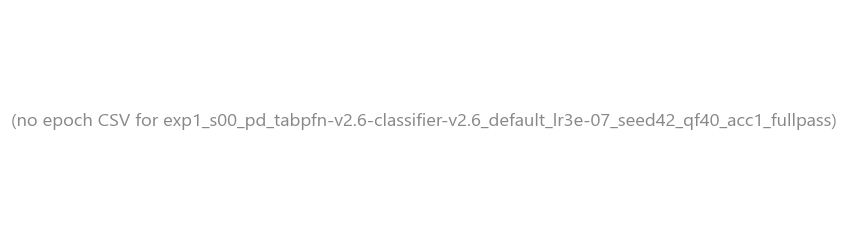

In [5]:
sink.save(plot_trial_dashboard(FOCUS_TRIAL, TRACK), 'trial_dashboard',
          caption="Four panels for the focus trial: training loss, learning-rate schedule, train and held-out monitoring metric, and wall-clock seconds, all against epoch.")

c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


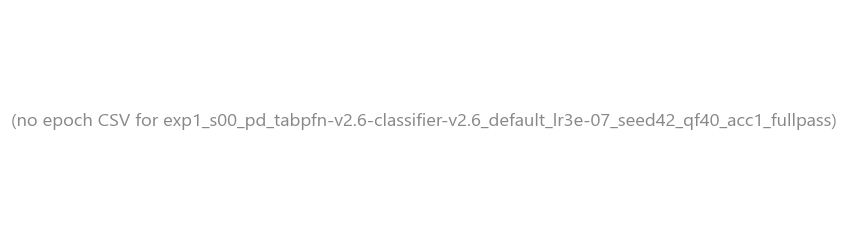

In [6]:
sink.save(plot_loss_curve(FOCUS_TRIAL, TRACK), 'loss_curve',
          caption="Training loss against epoch for the focus trial, averaged over the optimiser steps of each epoch.")

c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


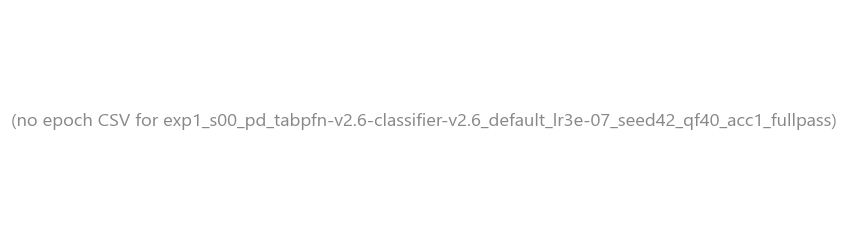

In [7]:
sink.save(plot_lr_schedule(FOCUS_TRIAL, TRACK), 'lr_schedule',
          caption="Learning rate against epoch for the focus trial: linear warmup followed by cosine decay to the configured floor.")

c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


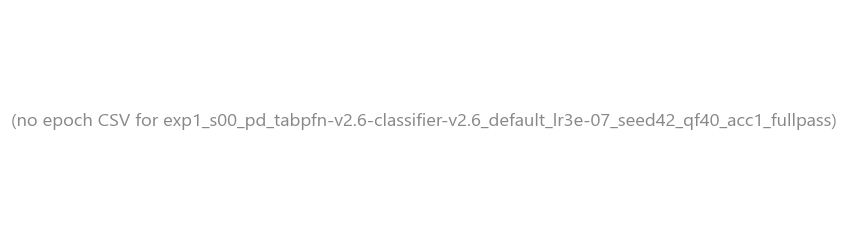

In [8]:
sink.save(plot_metric_curves(FOCUS_TRIAL, TRACK), 'metric_curves',
          caption="Monitoring metric against epoch for the focus trial, on the training datasets and on the held-out datasets, on twin axes. The monitor uses a fixed 2 000-row sample per dataset.")

c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


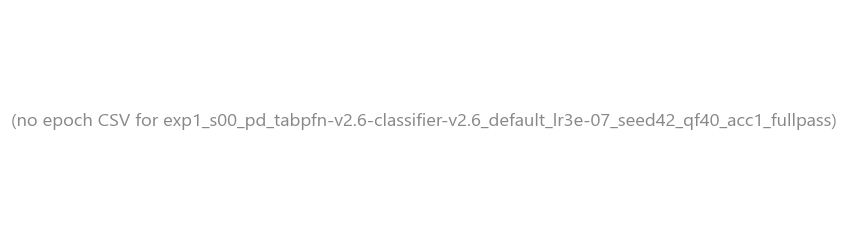

In [9]:
sink.save(plot_epoch_time(FOCUS_TRIAL, TRACK), 'epoch_time',
          caption="Wall-clock seconds per epoch for the focus trial.")

## 3 · Cross-trial overlays

Every trial on one axes. Colour = base checkpoint;
solid = no-LoRA, dashed = LoRA. Use these to spot regimes:

* If LoRA trials cluster well below no-LoRA ⇒ LoRA is hurting on
  this track and base.
* If one base sits clearly above the others throughout ⇒ pick that
  base as the headline checkpoint.
* If test_metric falls while train_metric keeps climbing ⇒ overfit
  starting; check the gap plot.

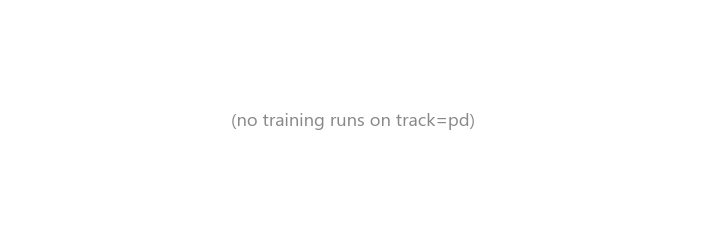

In [10]:
sink.save(plot_loss_overlay(TRACK), 'loss_overlay',
          caption="Training loss against epoch for every trial in the grid, one line per trial, coloured by base checkpoint and dashed for the adapter arm.")

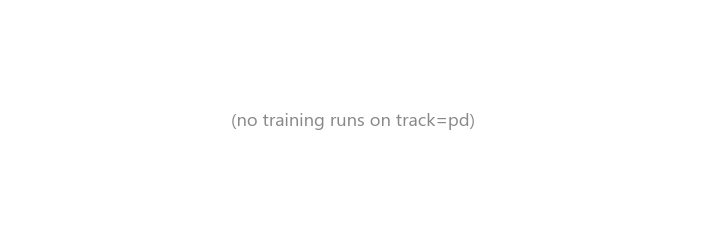

In [11]:
sink.save(plot_metric_overlay(TRACK, split='test'), 'metric_overlay',
          caption="Held-out monitoring metric against epoch for every trial, one line per trial, coloured by base checkpoint.")

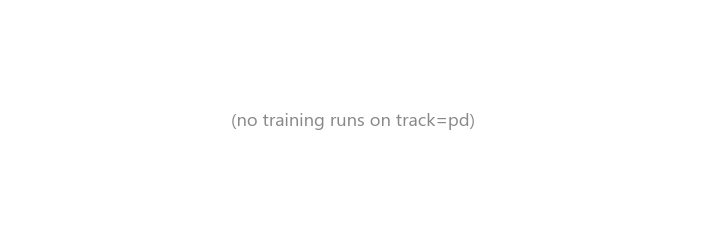

In [12]:
sink.save(plot_metric_overlay(TRACK, split='train'), 'metric_overlay',
          caption="Held-out monitoring metric against epoch for every trial, one line per trial, coloured by base checkpoint.")

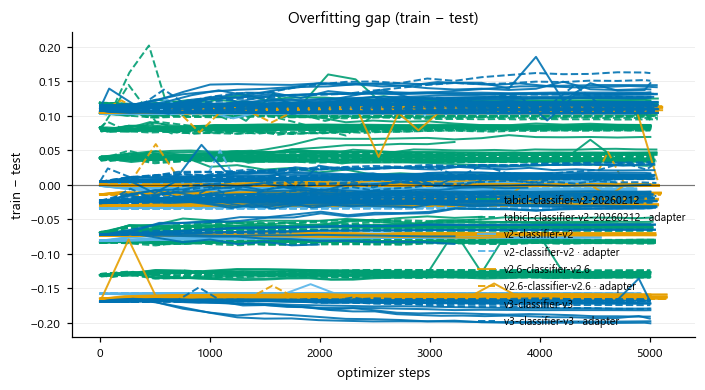

In [13]:
sink.save(plot_overfitting_diagnostic(TRACK), 'overfitting_diagnostic',
          caption="Training metric minus held-out metric against epoch, one line per trial. A rising line is the training corpus being fitted at the expense of unseen datasets.")

## 4 · Final-metric comparisons by hyperparameter

**`best_test_metric`** is the best test-set score the trial
achieved during training (max of `test_metric` for PD,
min for LGD).

**`final_test_metric`** is the last-epoch value (i.e. what the
checkpoint actually delivers on disk).

Swap the `metric=` kwarg below to view the latter instead.

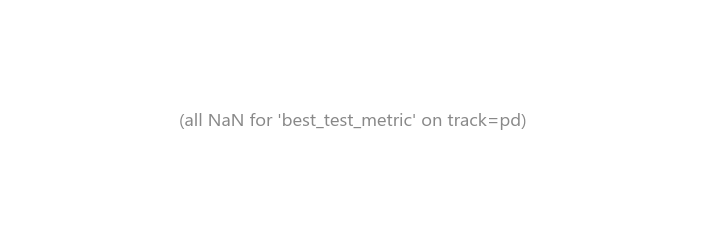

In [14]:
sink.save(plot_final_metric_bar(TRACK, metric='best_test_metric'), 'final_metric_bar',
          caption="Final monitoring metric per trial, sorted, one bar per trial, coloured by base checkpoint.")

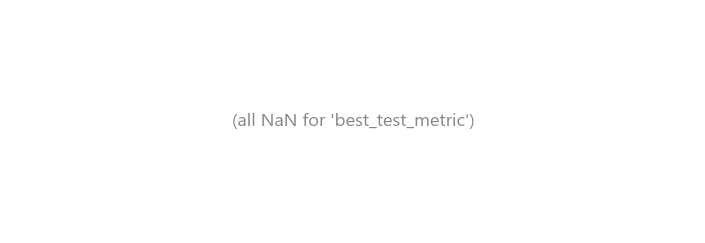

In [15]:
sink.save(plot_metric_heatmap(TRACK, metric='best_test_metric'), 'metric_heatmap',
          caption="Final monitoring metric over base checkpoint against learning rate, one panel per adaptation mode.")

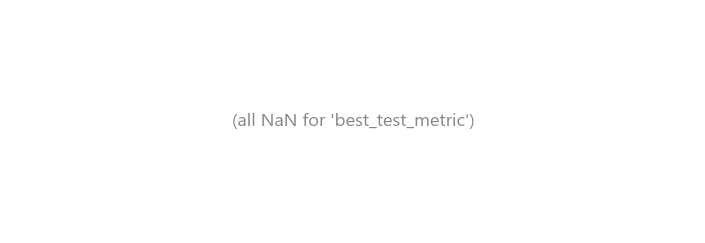

In [16]:
sink.save(plot_lr_effect(TRACK, metric='best_test_metric'), 'lr_effect',
          caption="Final monitoring metric against learning rate, one line per (base checkpoint, adaptation mode) pair.")

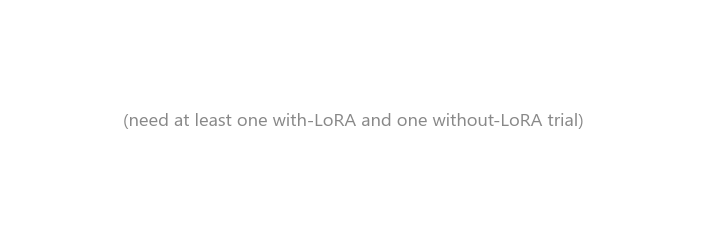

In [17]:
sink.save(plot_lora_effect(TRACK, metric='best_test_metric'), 'lora_effect',
          caption="Final monitoring metric of the full-finetuning arm against the adapter arm, paired within each (base, learning rate) pair. The diagonal marks equality.")

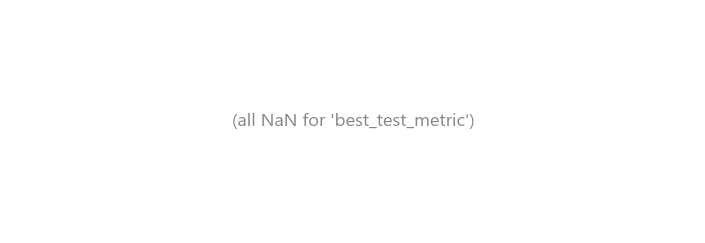

In [18]:
sink.save(plot_base_ranking(TRACK, metric='best_test_metric'), 'base_ranking',
          caption="Distribution of the final monitoring metric per base checkpoint, over all learning rates, adaptation modes and query fractions.")

## 5 · Time / accuracy trade-off

The Pareto-frontier-style scatter pairs **total training time** (x,
minutes) with the **final-epoch test metric** (y). A trial that
matches another's metric in less time pareto-dominates it.

The per-epoch bar plot underneath flags trials whose mean
seconds/epoch is unusually high — useful when one dataset's
chunk drags the whole epoch budget.

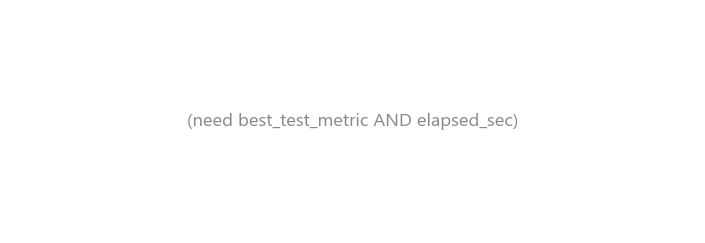

In [19]:
sink.save(plot_pareto_time_vs_metric(TRACK, metric='best_test_metric'), 'pareto_time_vs_metric',
          caption="Total training wall-clock against final monitoring metric, one point per trial, coloured by base checkpoint.")

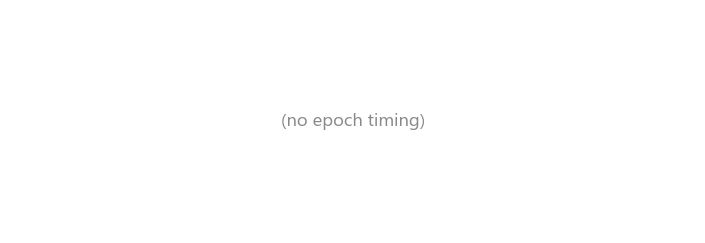

In [20]:
sink.save(plot_epoch_time_overlay(TRACK), 'epoch_time_overlay',
          caption="Median seconds per epoch per trial, one bar per trial, coloured by base checkpoint.")

## 6 · Convergence diagnostics

Where in the training budget does the best test metric appear?

* Most mass at < 30 % ⇒ early stop is leaving training cycles on
  the floor; consider shorter epochs or a stricter LR schedule.
* Most mass at > 80 % ⇒ trials are still improving when training
  ends; increase `cfg.train.epochs` before re-launching the sweep.

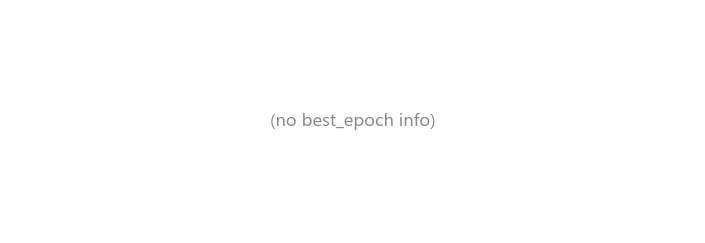

In [21]:
sink.save(plot_convergence_speed(TRACK), 'convergence_speed',
          caption="Distribution of the epoch at which each trial reached its best held-out monitoring metric.")

## 7 · Failures and leaderboard

`failed_trials()` surfaces any FAIL rows from the manifest with
their error string — most often a `CUDA OOM` from a too-large
`n_finetune_ctx_plus_query_samples`. The leaderboard at the end
is the canonical sorted view used to pick the headline
checkpoint for eval.

In [22]:
failures = failed_trials(TRACK)
if failures.empty:
    print('No failed trials. ✔')
else:
    display(failures)

No failed trials. ✔


In [23]:
trial_leaderboard(TRACK)

,trial_name,base_short,learning_rate,use_lora,seed,metric_name,best_test_metric,best_epoch,final_test_metric,final_train_metric,n_epochs,mean_epoch_sec,elapsed_sec,status
0,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,3.000000e-07,False,42,,NaN,NaN,NaN,NaN,NaN,NaN,3608.415652,OK
1,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,1.000000e-05,False,42,,NaN,NaN,NaN,NaN,NaN,NaN,3597.530767,OK
2,exp1_s00_pd_tabpfn-v2.6-classifier-v2.6_defaul...,v2.6-classifier-v2.6,1.000000e-06,False,42,,NaN,NaN,NaN,NaN,NaN,NaN,3608.117255,OK
3,exp1_s00_pd_tabpfn-v2-classifier-v2_default_lr...,v2-classifier-v2,1.000000e-05,False,42,,NaN,NaN,NaN,NaN,NaN,NaN,4520.120955,OK
4,exp1_s00_pd_tabpfn-v2-classifier-v2_default_lr...,v2-classifier-v2,1.000000e-06,False,42,,NaN,NaN,NaN,NaN,NaN,NaN,4513.120400,OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1441,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,1.000000e-06,False,42,,NaN,NaN,NaN,NaN,NaN,NaN,32821.129784,OK
1442,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,1.000000e-05,False,42,,NaN,NaN,NaN,NaN,NaN,NaN,32835.155177,OK
1443,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,1.000000e-05,True,42,,NaN,NaN,NaN,NaN,NaN,NaN,32117.727897,OK
1444,exp1_s07_pd_tabicl-classifier-v2-20260212_lr1e...,tabicl-classifier-v2-20260212,1.000000e-05,False,42,,NaN,NaN,NaN,NaN,NaN,NaN,32909.706293,OK


## 8 · Did the model actually move?

`drift__<stage>` is $\|w - w_0\|$ over one top-level module of the model, recorded on
every monitored epoch. This is the plot that reframed run-5: a trial whose drift stays
flat near zero has **not trained**, so its "no effect" result says nothing about
continued pretraining. Below it, the per-dataset loss shows *which* tables the model is
learning — a corpus loss that falls while one dataset's loss rises is the model trading
one table off against the others.

C:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\src\visualize\figures.py:137: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(path, format="pdf", dpi=DPI)
c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


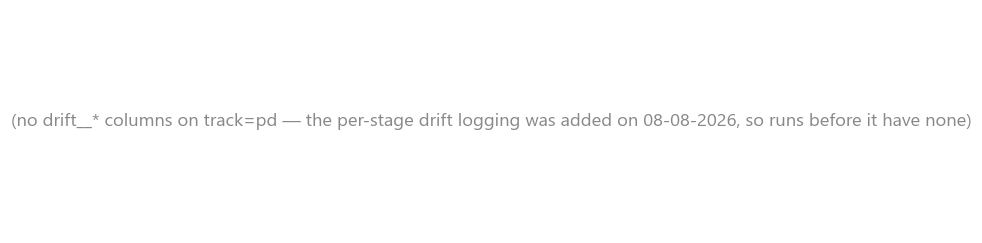

In [24]:
sink.save(plot_weight_drift(TRACK), 'weight_drift',
          caption="Distance of each trial's weights from its base checkpoint against epoch, on a log axis, taking the maximum over the model's top-level stages. One line per trial, coloured by base checkpoint.")


c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
c:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


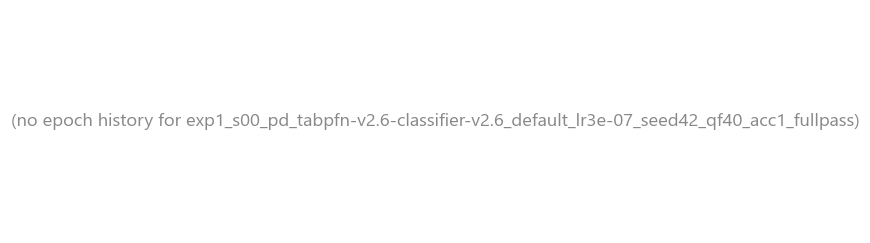

In [25]:
sink.save(plot_per_dataset_loss(FOCUS_TRIAL, TRACK), 'per_dataset_loss',
          caption="Mean training loss per dataset against epoch for the focus trial, one line per training dataset, ordered in the legend by final loss.")


## Summary

Everything above, as text. This is the block `src/utils/run_notebooks.py`
collects into `output/All_Results.md`, so it has to stand on its own: section
order follows this notebook's, and every figure's headline number is restated
here rather than living only inside a PDF.

In [26]:
from src.visualize import summaries

print(summaries.training_summary(TRACK))
print()
print(sink.summary())

  1.0. PD TRAINING
  continued pretraining — what the sweep did, not whether it helped


1. Trials
---------
  trials           : 1446
    OK             1446

2. Budget actually realised
---------------------------
  optimizer steps  4554 - 5152
  epochs           21 - 385
  steps/epoch      13 - 245
  passes over corpus : 20 - 385   (Garg 2025: ~280 over 71 tables)

3. The corpus this sweep trained on
-----------------------------------
  train datasets     13
  held-out datasets  4
  train rows         [1044281, 1491313, 1518657, 1607368, 1909220, 2071149, 2171000, 2397824]
  held-out rows      [89061, 315885, 415736, 577665, 879517, 968228, 995572, 1442604]
  train ids (13): GMSC, Taiwan Credit Card, Vehicle Loan, LendingClub, Hackerearth, Cobranded ...
  held-out ids (4): Myhom, PropPD1, Thomas, Home Credit

4. The grid actually run
------------------------
  bases            4: tabicl-classifier-v2-20260212, tabpfn-v2-classifier-v2_default, tabpfn-v2.6-classifier-v2.6_default, ta